<a href="https://colab.research.google.com/github/Tejas-srivastava505/IAI_Project/blob/tejas/03_step2_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 step2_train.py — EfficientNetB0 Transfer Learning
**KrishiAI · IT-A · 2024-25**

### ✅ Yes — all models save directly to Google Drive
Every checkpoint and the final model write to `/content/drive/MyDrive/KrishiAI/models/` as they are created.

### ✅ Auto-resume — never loses progress
When you re-run this notebook after a Colab timeout or disconnect, it automatically detects what is already saved in Drive and picks up from where it left off instead of starting from scratch.

| Checkpoint found in Drive | What happens |
|--------------------------|-------------|
| Nothing | Starts Phase 1 from scratch |
| `best_phase1.keras` only | Skips Phase 1, starts Phase 2 |
| `best_phase2.keras` | Resumes Phase 2 from last saved epoch |
| `krishiai_final.keras` | Skips everything, prints done |

### ▶️ How to run
**Runtime → Restart and Run All** — always run all cells top to bottom.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/KrishiAI', exist_ok=True)
print('✅ Drive mounted')

Mounted at /content/drive
✅ Drive mounted


In [ ]:
!pip install tensorflow tensorflow-datasets --quiet
!pip install opencv-python-headless Pillow tqdm seaborn scikit-learn --quiet
print('✅ Packages ready')

✅ Packages ready


In [ ]:
import os, sys, json, time
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard, CSVLogger
)
tf.random.set_seed(42)
np.random.seed(42)
print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## ⚙️ Config — all paths point to Google Drive

In [ ]:
# ── config.py — KrishiAI Project Configuration ─────────────────────────────
import os

BASE_DIR       = "/content/drive/MyDrive/KrishiAI"
DATA_RAW_DIR   = os.path.join(BASE_DIR, "data", "raw")
DATA_CLEAN_DIR = os.path.join(BASE_DIR, "data", "cleaned")
DATA_PROC_DIR  = os.path.join(BASE_DIR, "data", "processed")
MODELS_DIR     = os.path.join(BASE_DIR, "models")
TFLITE_DIR     = os.path.join(BASE_DIR, "tflite")
LOGS_DIR       = os.path.join(BASE_DIR, "logs")
PLOTS_DIR      = os.path.join(BASE_DIR, "plots")

for d in [DATA_RAW_DIR, DATA_CLEAN_DIR, DATA_PROC_DIR,
          MODELS_DIR, TFLITE_DIR, LOGS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

DISEASE_CLASSES = {
    "Rice___Leaf_blast":                   "Rice Blast",
    "Rice___Bacterial_leaf_blight":        "Bacterial Leaf Blight",
    "Rice___Brown_spot":                   "Brown Spot",
    "Rice___healthy":                      "Healthy Rice",
    "Corn_(maize)___Northern_Leaf_Blight": "Leaf Blight (proxy)",
    "Corn_(maize)___healthy":              "Healthy Crop (proxy)",
    "Tomato___Late_blight":                "Fungal Blight (proxy)",
    "Tomato___healthy":                    "Healthy Crop (proxy)",
}
CLASS_NAMES = [
    "Rice Blast","Bacterial Blight","Brown Spot","Healthy Rice",
    "Leaf Blight","Fungal Blight","Healthy Crop",
]
NUM_CLASSES            = len(CLASS_NAMES)
IMAGE_SIZE             = (224, 224)
BATCH_SIZE             = 32
EPOCHS_FROZEN          = 10
EPOCHS_FINETUNE        = 20
LEARNING_RATE_HEAD     = 1e-3
LEARNING_RATE_FINETUNE = 1e-5
DROPOUT_RATE           = 0.3
L2_LAMBDA              = 1e-4
TRAIN_SPLIT            = 0.70
VAL_SPLIT              = 0.15
TEST_SPLIT             = 0.15
RANDOM_SEED            = 42
MIN_IMAGE_SIZE_BYTES   = 2_000
MIN_PIXEL_DIMENSION    = 64
MAX_BLUR_VARIANCE      = 10.0
TFLITE_MODEL_NAME      = "krishiai_efficientnetb0_int8.tflite"
TFLITE_TARGET_MB       = 4.0

KANNADA_ALERTS = {
    "Rice Blast":       "ಭತ್ತದ ಬ್ಲಾಸ್ಟ್ ರೋಗ ಪತ್ತೆ. ಟ್ರೈಸೈಕ್ಲಾಜ಼ೋಲ್ ತಕ್ಷಣ ಸಿಂಪಡಿಸಿ.",
    "Bacterial Blight": "ಬ್ಯಾಕ್ಟೀರಿಯಲ್ ಎಲೆ ಒಣಗುವಿಕೆ. ಕಾಪರ್ ಆಕ್ಸಿಕ್ಲೋರೈಡ್ ಬಳಸಿ.",
    "Brown Spot":       "ಕಂದು ಚುಕ್ಕೆ ರೋಗ. ಮ್ಯಾಂಕೋಜ಼ೆಬ್ ಬಳಸಿ.",
    "Healthy Rice":     "ಬೆಳೆ ಆರೋಗ್ಯಕರವಾಗಿದೆ. ಮೇಲ್ವಿಚಾರಣೆ ಮುಂದುವರಿಸಿ.",
    "Leaf Blight":      "ಎಲೆ ಒಣಗುವ ರೋಗ. KVK ಸಂಪರ್ಕಿಸಿ.",
    "Fungal Blight":    "ಶಿಲೀಂಧ್ರ ರೋಗ ಪತ್ತೆ. ಶಿಲೀಂಧ್ರನಾಶಕ ಸಿಂಪಡಿಸಿ.",
    "Healthy Crop":     "ಬೆಳೆ ಆರೋಗ್ಯಕರ. ನಿಯಮಿತ ತಪಾಸಣೆ ಮಾಡಿ.",
}
TREATMENT_MAP = {
    "Rice Blast":       ["Tricyclazole 75WP @ 0.6 g/L","Isoprothiolane 40EC @ 1.5 mL/L","Avoid excess nitrogen","Drain stagnant water"],
    "Bacterial Blight": ["Copper Oxychloride 50WP @ 3 g/L","Streptocycline @ 0.5 g/L","Avoid flood irrigation","Remove infected debris"],
    "Brown Spot":       ["Mancozeb 75WP @ 2.5 g/L","Propiconazole 25EC @ 1 mL/L","Correct potassium deficiency"],
    "Healthy Rice":     ["Continue regular monitoring","Preventive fungicide (optional at tillering)"],
    "Leaf Blight":      ["Copper-based fungicide","Consult KVK Udupi: 0820-2520842"],
    "Fungal Blight":    ["Mancozeb + Carbendazim combo","Improve field drainage"],
    "Healthy Crop":     ["Continue monitoring","Check weekly during monsoon"],
}

print(f"✅ Config loaded  —  BASE_DIR = {BASE_DIR}")
print(f"   MODELS_DIR : {MODELS_DIR}")
print(f"   LOGS_DIR   : {LOGS_DIR}")
print(f"   Classes    : {NUM_CLASSES}")


✅ Config loaded  —  BASE_DIR = /content/drive/MyDrive/KrishiAI
   MODELS_DIR : /content/drive/MyDrive/KrishiAI/models
   LOGS_DIR   : /content/drive/MyDrive/KrishiAI/logs
   Classes    : 7


## 🔧 Fix Manifest Paths
> Safe to run any number of times — always produces the correct path.

In [ ]:
# ── FIX MANIFEST PATHS (safe to run any number of times) ────────────────────
import pandas as pd, re

CORRECT = "/content/drive/MyDrive/KrishiAI/"

for split in ["train", "val", "test"]:
    csv = os.path.join(LOGS_DIR, f"{split}_manifest.csv")
    df  = pd.read_csv(csv)
    df["path"] = df["path"].apply(
        lambda p: CORRECT + re.sub(r"^.*?(data/)", r"\1", p)
    )
    df.to_csv(csv, index=False)
    print(f"✅ {split}_manifest.csv paths fixed")

sample = pd.read_csv(os.path.join(LOGS_DIR, "train_manifest.csv"))["path"].iloc[0]
exists = os.path.exists(sample)
print(f"\nSample path : {sample}")
print(f"File exists : {'✅ YES — ready to train!' if exists else '❌ NO — re-run 02_step1_data_pipeline.ipynb'}")

if not exists:
    raise FileNotFoundError(
        "Images not found at the Drive path.\n"
        "Go back and re-run 02_step1_data_pipeline.ipynb with BASE_DIR pointing to Drive."
    )


✅ train_manifest.csv paths fixed
✅ val_manifest.csv paths fixed
✅ test_manifest.csv paths fixed

Sample path : /content/drive/MyDrive/KrishiAI/data/cleaned/Tomato___Late_blight/8daa69460466.jpg
File exists : ✅ YES — ready to train!


## 📚 Function Definitions

In [ ]:
# =============================================================================
# step2_train.py — Build EfficientNetB0 + Train in Two Phases
#
# Architecture:
#   EfficientNetB0 (pretrained ImageNet) → GlobalAveragePooling → Dropout
#   → Dense(256, relu) → Dropout → Dense(NUM_CLASSES, softmax)
#
# Training strategy (standard transfer learning):
#   Phase 1  — Freeze EfficientNetB0 base; train only the new head (10 epochs)
#   Phase 2  — Unfreeze top ~30 layers of base; fine-tune at very low LR (20 epochs)
#
# Run: python step2_train.py
# =============================================================================

import os, sys, json, time

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint,
    TensorBoard, CSVLogger
)
import matplotlib
# (inline mode set by %matplotlib inline)
import matplotlib.pyplot as plt


# ── Reproducibility ───────────────────────────────────────────────────────────
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"TensorFlow {tf.__version__}  |  GPU: {tf.config.list_physical_devices('GPU')}")


# ──────────────────────────────────────────────────────────────────────────────
# REBUILD DATASETS FROM SAVED MANIFESTS
# (So step2 can run independently from step1 once data is prepared.)
# ──────────────────────────────────────────────────────────────────────────────

def load_datasets_from_manifests():
    """Load the train/val/test manifests saved by step1 and rebuild tf.data."""
    AUTOTUNE = tf.data.AUTOTUNE

    def pairs_from_csv(name):
        df = pd.read_csv(os.path.join(LOGS_DIR, f"{name}_manifest.csv"))
        return list(zip(df["path"].tolist(), df["label"].tolist()))

    def make_ds(pairs, augment=False, shuffle=False):
        paths  = [p for p, _ in pairs]
        labels = [l for _, l in pairs]
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        if shuffle:
            ds = ds.shuffle(len(pairs), seed=RANDOM_SEED, reshuffle_each_iteration=True)
        ds = ds.map(lambda p, l: _load_image(p, l, augment), num_parallel_calls=AUTOTUNE)
        ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
        return ds, len(pairs)

    train_ds, n_train = make_ds(pairs_from_csv("train"), augment=True,  shuffle=True)
    val_ds,   n_val   = make_ds(pairs_from_csv("val"),   augment=False, shuffle=False)
    test_ds,  n_test  = make_ds(pairs_from_csv("test"),  augment=False, shuffle=False)

    print(f"  train={n_train}  val={n_val}  test={n_test}")
    return train_ds, val_ds, test_ds


@tf.function
def _load_image(path, label, augment):
    """Load, decode, preprocess (EfficientNet expects [0,255] float32)."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32)   # EfficientNet preprocessor handles normalisation

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)                # rotation proxy
        img = tf.image.random_brightness(img, max_delta=0.25 * 255)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.image.random_saturation(img, lower=0.7, upper=1.3)
        img = tf.image.random_hue(img, max_delta=0.05)
        img = tf.clip_by_value(img, 0.0, 255.0)

    # EfficientNet built-in preprocessor (scales to [-1, 1] internally)
    img = preprocess_input(img)
    label_one_hot = tf.one_hot(label, NUM_CLASSES)
    return img, label_one_hot


# ──────────────────────────────────────────────────────────────────────────────
# MODEL ARCHITECTURE
# ──────────────────────────────────────────────────────────────────────────────

def build_model(num_classes: int = NUM_CLASSES, trainable_base: bool = False):
    """
    Build the KrishiAI classification model.

    Architecture:
        Input (224x224x3)
        → EfficientNetB0 base (pretrained, optionally frozen)
        → GlobalAveragePooling2D          # reduces spatial dims
        → BatchNormalization
        → Dropout(0.3)
        → Dense(256, relu, L2)            # custom head
        → BatchNormalization
        → Dropout(0.3)
        → Dense(NUM_CLASSES, softmax)     # disease probability

    Args:
        trainable_base: If False (Phase 1), all EfficientNetB0 weights are frozen.
                        If True  (Phase 2), top layers are unfrozen for fine-tuning.
    """
    # ── Base model ────────────────────────────────────────────────────────────
    base = EfficientNetB0(
        weights="imagenet",          # use ImageNet pretrained weights
        include_top=False,           # remove ImageNet classification head
        input_shape=(*IMAGE_SIZE, 3)
    )

    if not trainable_base:
        # Phase 1: Freeze the entire base
        base.trainable = False
        print("  Base frozen (Phase 1 — head-only training)")
    else:
        # Phase 2: Unfreeze only the top ~30 layers
        base.trainable = True
        for layer in base.layers[:-30]:
            layer.trainable = False
        trainable_count = sum(1 for l in base.layers if l.trainable)
        print(f"  Base partially unfrozen ({trainable_count}/{len(base.layers)} layers trainable, Phase 2)")

    # ── Build full model with Functional API ─────────────────────────────────
    inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name="crop_image")

    # Feature extraction
    x = base(inputs, training=False)          # training=False keeps BN frozen in Phase 1
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Dropout(DROPOUT_RATE, name="drop1")(x)

    # Classification head
    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_LAMBDA),
        name="dense_head"
    )(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Dropout(DROPOUT_RATE, name="drop2")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="KrishiAI_EfficientNetB0")
    return model, base


# ──────────────────────────────────────────────────────────────────────────────
# CALLBACKS
# ──────────────────────────────────────────────────────────────────────────────

def get_callbacks(phase: int) -> list:
    """
    Returns the list of Keras callbacks for a given training phase.
    phase=1 → head training | phase=2 → fine-tuning
    """
    checkpoint_path = os.path.join(MODELS_DIR, f"best_phase{phase}.keras")

    callbacks = [
        # Save the best model by validation accuracy
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_accuracy",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),
        # Reduce learning rate if val_loss plateaus
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        # Stop early if val_loss doesn't improve for 7 epochs
        EarlyStopping(
            monitor="val_loss",
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        # Log metrics to CSV
        CSVLogger(
            os.path.join(LOGS_DIR, f"phase{phase}_training_log.csv"),
            append=False
        ),
        # TensorBoard logs
        TensorBoard(
            log_dir=os.path.join(LOGS_DIR, f"tensorboard_phase{phase}"),
            histogram_freq=1
        ),
    ]
    return callbacks, checkpoint_path


# ──────────────────────────────────────────────────────────────────────────────
# LOAD CLASS WEIGHTS
# ──────────────────────────────────────────────────────────────────────────────

def load_class_weights():
    path = os.path.join(LOGS_DIR, "class_weights.json")
    if os.path.exists(path):
        with open(path) as f:
            raw = json.load(f)
        return {int(k): v for k, v in raw.items()}
    else:
        print("  [WARN] class_weights.json not found — using uniform weights")
        return None


# ──────────────────────────────────────────────────────────────────────────────
# PLOT TRAINING HISTORY
# ──────────────────────────────────────────────────────────────────────────────

def plot_history(history, phase_label: str, filename: str):
    """Save loss + accuracy curves for one training phase."""
    epochs = range(1, len(history.history["loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#0a150a")

    for ax in (ax1, ax2):
        ax.set_facecolor("#0f1f0f")
        ax.tick_params(colors="white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
        ax.title.set_color("white")
        ax.spines[:].set_color("#1a3d1a")

    # Loss
    ax1.plot(epochs, history.history["loss"],     color="#7ec850", lw=2, label="Train Loss")
    ax1.plot(epochs, history.history["val_loss"], color="#ff8c00", lw=2, linestyle="--", label="Val Loss")
    ax1.set_title(f"Loss — {phase_label}")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(labelcolor="white", framealpha=0.2)
    ax1.grid(alpha=0.2, color="#1a3d1a")

    # Accuracy
    ax2.plot(epochs, history.history["accuracy"],     color="#7ec850", lw=2, label="Train Acc")
    ax2.plot(epochs, history.history["val_accuracy"], color="#ff8c00", lw=2, linestyle="--", label="Val Acc")
    ax2.set_title(f"Accuracy — {phase_label}")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.legend(labelcolor="white", framealpha=0.2)
    ax2.grid(alpha=0.2, color="#1a3d1a")

    plt.suptitle(f"KrishiAI Training — {phase_label}", color="white", fontsize=13, y=1.01)
    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Training curve saved → {path}")


# ──────────────────────────────────────────────────────────────────────────────
# MAIN TRAINING LOOP
# ──────────────────────────────────────────────────────────────────────────────

def train():
    print("╔══════════════════════════════════════════════════════════╗")
    print("║        KrishiAI — Model Training (Step 2 of 4)          ║")
    print("║     EfficientNetB0 Transfer Learning — Two Phases       ║")
    print("╚══════════════════════════════════════════════════════════╝")

    # ── Load data ─────────────────────────────────────────────────────────────
    print("\n[1/2] Loading datasets from manifests...")
    train_ds, val_ds, test_ds = load_datasets_from_manifests()
    class_weights = load_class_weights()

    # ── PHASE 1: Train the head only ──────────────────────────────────────────
    print("\n" + "="*60)
    print("PHASE 1 — Training Classification Head (base frozen)")
    print("="*60)
    print(f"  Epochs: {EPOCHS_FROZEN}  LR: {LEARNING_RATE_HEAD}")

    model, base = build_model(trainable_base=False)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_HEAD),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy"),
            keras.metrics.AUC(name="auc", multi_label=False),
        ]
    )
    model.summary()

    print(f"\n  Trainable params: {model.count_params():,}")
    callbacks_p1, ckpt_p1 = get_callbacks(phase=1)
    t0 = time.time()
    hist1 = model.fit(
        train_ds,
        epochs=EPOCHS_FROZEN,
        validation_data=val_ds,
        callbacks=callbacks_p1,
        class_weight=class_weights,
        verbose=1,
    )
    t1 = time.time()
    print(f"\n  Phase 1 complete in {(t1-t0)/60:.1f} min")
    print(f"  Best val accuracy: {max(hist1.history['val_accuracy']):.4f}")
    plot_history(hist1, "Phase 1 — Head Only", "phase1_training_curves.png")

    # Load best Phase 1 checkpoint
    print(f"\n  Loading best Phase 1 checkpoint: {ckpt_p1}")
    model = keras.models.load_model(ckpt_p1)

    # ── PHASE 2: Fine-tune top layers ─────────────────────────────────────────
    print("\n" + "="*60)
    print("PHASE 2 — Fine-tuning Top Layers (partial unfreeze)")
    print("="*60)
    print(f"  Epochs: {EPOCHS_FINETUNE}  LR: {LEARNING_RATE_FINETUNE}")

    # Unfreeze top 30 layers of the EfficientNetB0 base
    base_layer = model.get_layer("efficientnetb0")
    base_layer.trainable = True
    for layer in base_layer.layers[:-30]:
        layer.trainable = False

    # Re-compile with much smaller LR to avoid catastrophic forgetting
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_FINETUNE),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy"),
            keras.metrics.AUC(name="auc", multi_label=False),
        ]
    )

    callbacks_p2, ckpt_p2 = get_callbacks(phase=2)
    t2 = time.time()
    hist2 = model.fit(
        train_ds,
        epochs=EPOCHS_FINETUNE,
        validation_data=val_ds,
        callbacks=callbacks_p2,
        class_weight=class_weights,
        verbose=1,
    )
    t3 = time.time()
    print(f"\n  Phase 2 complete in {(t3-t2)/60:.1f} min")
    print(f"  Best val accuracy: {max(hist2.history['val_accuracy']):.4f}")
    plot_history(hist2, "Phase 2 — Fine-tuning", "phase2_training_curves.png")

    # ── Save final model ──────────────────────────────────────────────────────
    final_model = keras.models.load_model(ckpt_p2)
    final_path  = os.path.join(MODELS_DIR, "krishiai_final.keras")
    final_model.save(final_path)
    print(f"\n  Final model saved → {final_path}")

    # ── Quick evaluation on val set ───────────────────────────────────────────
    print("\n  Quick evaluation on validation set:")
    val_results = final_model.evaluate(val_ds, verbose=0)
    for name, val in zip(final_model.metrics_names, val_results):
        print(f"    {name:<25} {val:.4f}")

    # Save combined history
    all_history = {
        "phase1_accuracy": hist1.history["accuracy"],
        "phase1_val_accuracy": hist1.history["val_accuracy"],
        "phase1_loss": hist1.history["loss"],
        "phase1_val_loss": hist1.history["val_loss"],
        "phase2_accuracy": hist2.history["accuracy"],
        "phase2_val_accuracy": hist2.history["val_accuracy"],
        "phase2_loss": hist2.history["loss"],
        "phase2_val_loss": hist2.history["val_loss"],
    }
    with open(os.path.join(LOGS_DIR, "training_history.json"), "w") as f:
        json.dump(all_history, f)

    print(f"\n✅ Training complete!")
    print(f"   Final model → {final_path}")
    print(f"\nNext step: python step3_evaluate.py")
    return final_model



TensorFlow 2.19.0  |  GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 🔍 Check Drive for Existing Checkpoints

In [ ]:
# ── CHECK WHAT'S ALREADY SAVED IN DRIVE ─────────────────────────────────────
# This cell decides whether to START fresh or RESUME from where you left off.
# It checks Google Drive for existing checkpoints and training history,
# then sets flags used by the training cells below.

import json as _json

CKPT_P1   = os.path.join(MODELS_DIR, "best_phase1.keras")
CKPT_P2   = os.path.join(MODELS_DIR, "best_phase2.keras")
FINAL     = os.path.join(MODELS_DIR, "krishiai_final.keras")
HIST_FILE = os.path.join(LOGS_DIR,   "training_history.json")

p1_exists    = os.path.exists(CKPT_P1)
p2_exists    = os.path.exists(CKPT_P2)
final_exists = os.path.exists(FINAL)
hist_exists  = os.path.exists(HIST_FILE)

print("=" * 55)
print("CHECKPOINT STATUS  (Google Drive)")
print("=" * 55)
print(f"  {'✅' if p1_exists else '⬜'}  Phase 1 checkpoint  best_phase1.keras"
      + (f"  ({os.path.getsize(CKPT_P1)/1e6:.1f} MB)" if p1_exists else "  ← not found"))
print(f"  {'✅' if p2_exists else '⬜'}  Phase 2 checkpoint  best_phase2.keras"
      + (f"  ({os.path.getsize(CKPT_P2)/1e6:.1f} MB)" if p2_exists else "  ← not found"))
print(f"  {'✅' if final_exists else '⬜'}  Final model         krishiai_final.keras"
      + (f"  ({os.path.getsize(FINAL)/1e6:.1f} MB)" if final_exists else "  ← not found"))
print(f"  {'✅' if hist_exists else '⬜'}  Training history    training_history.json")
print()

# ── Decide training state ────────────────────────────────────────────────────
if final_exists:
    TRAIN_STATE = "DONE"
elif p2_exists:
    TRAIN_STATE = "RESUME_P2"   # Phase 1 done, resume Phase 2
elif p1_exists:
    TRAIN_STATE = "RESUME_P2"   # Phase 1 done, start/resume Phase 2
else:
    TRAIN_STATE = "FRESH"       # Nothing saved, start from scratch

# Load existing history if available (we'll append new epochs to it)
if hist_exists:
    with open(HIST_FILE) as _f:
        SAVED_HISTORY = _json.load(_f)
    # Figure out how many epochs were already completed
    p1_done = len(SAVED_HISTORY.get("phase1_accuracy", []))
    p2_done = len(SAVED_HISTORY.get("phase2_accuracy", []))
else:
    SAVED_HISTORY = {}
    p1_done = 0
    p2_done = 0

# Remaining epochs to run
P1_EPOCHS_LEFT = max(0, EPOCHS_FROZEN   - p1_done)
P2_EPOCHS_LEFT = max(0, EPOCHS_FINETUNE - p2_done)

print(f"Training state   : {TRAIN_STATE}")
print(f"Phase 1 done     : {p1_done} / {EPOCHS_FROZEN} epochs  →  {P1_EPOCHS_LEFT} left")
print(f"Phase 2 done     : {p2_done} / {EPOCHS_FINETUNE} epochs  →  {P2_EPOCHS_LEFT} left")
print()

if TRAIN_STATE == "DONE":
    print("🎉 Training is already complete!")
    print(f"   Final model is at: {FINAL}")
    print("   You can skip to 04_step3_evaluate.ipynb")
elif TRAIN_STATE == "RESUME_P2" and p1_exists:
    print(f"▶️  Will RESUME Phase 2 from checkpoint (skipping Phase 1).")
    print(f"   Loading: {CKPT_P2 if p2_exists else CKPT_P1}")
elif TRAIN_STATE == "FRESH":
    print("▶️  No checkpoints found — starting fresh training from scratch.")


CHECKPOINT STATUS  (Google Drive)
  ✅  Phase 1 checkpoint  best_phase1.keras  (21.1 MB)
  ✅  Phase 2 checkpoint  best_phase2.keras  (33.1 MB)
  ✅  Final model         krishiai_final.keras  (33.1 MB)
  ✅  Training history    training_history.json

Training state   : DONE
Phase 1 done     : 0 / 10 epochs  →  10 left
Phase 2 done     : 0 / 20 epochs  →  20 left

🎉 Training is already complete!
   Final model is at: /content/drive/MyDrive/KrishiAI/models/krishiai_final.keras
   You can skip to 04_step3_evaluate.ipynb


## ▶️ Load Datasets

In [ ]:
# Load datasets from the fixed manifests
print("Loading datasets...")
train_ds, val_ds, test_ds = load_datasets_from_manifests()
class_weights = load_class_weights()
print(f"\nClass weights: {class_weights}")


Loading datasets...
  train=2441  val=522  test=522

Class weights: {0: 1.0, 1: 1.1987381703470033}


## ▶️ Phase 1 — Train Classification Head
> Automatically **skipped** if `best_phase1.keras` already exists in Drive.

In [ ]:
# ── PHASE 1 — Train classification head ─────────────────────────────────────
# Automatically skipped if a Phase 1 checkpoint already exists in Drive.

if TRAIN_STATE == "DONE":
    print("⏭️  Training already complete — skipping Phase 1.")
    hist1 = None

elif p1_exists and P1_EPOCHS_LEFT == 0:
    # Phase 1 fully done in a previous run — just load the checkpoint
    print(f"⏭️  Phase 1 already finished ({p1_done} epochs). Loading checkpoint...")
    model = keras.models.load_model(CKPT_P1)
    ckpt_p1 = CKPT_P1
    hist1 = None
    print(f"   ✅ Loaded: {CKPT_P1}")

else:
    if p1_exists and P1_EPOCHS_LEFT > 0:
        # Partially done — resume from checkpoint
        print(f"▶️  Resuming Phase 1 from checkpoint ({p1_done} epochs done, {P1_EPOCHS_LEFT} left)...")
        model = keras.models.load_model(CKPT_P1)
        ckpt_p1 = CKPT_P1
    else:
        # Fresh start
        print(f"▶️  Starting Phase 1 from scratch ({EPOCHS_FROZEN} epochs)...")
        model, base = build_model(trainable_base=False)
        ckpt_p1 = CKPT_P1

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_HEAD),
        loss="categorical_crossentropy",
        metrics=["accuracy",
                 keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy"),
                 keras.metrics.AUC(name="auc", multi_label=False)]
    )
    model.summary()

    callbacks_p1, _ = get_callbacks(phase=1)
    t0 = time.time()
    hist1 = model.fit(
        train_ds,
        epochs=P1_EPOCHS_LEFT,          # only run remaining epochs
        validation_data=val_ds,
        callbacks=callbacks_p1,
        class_weight=class_weights,
        verbose=1,
    )
    print(f"\n✅ Phase 1 done in {(time.time()-t0)/60:.1f} min")
    print(f"   Best val accuracy: {max(hist1.history['val_accuracy']):.4f}")
    plot_history(hist1, "Phase 1 — Head Only", "phase1_training_curves.png")
    print(f"   Checkpoint saved to Drive: {CKPT_P1}")


⏭️  Training already complete — skipping Phase 1.


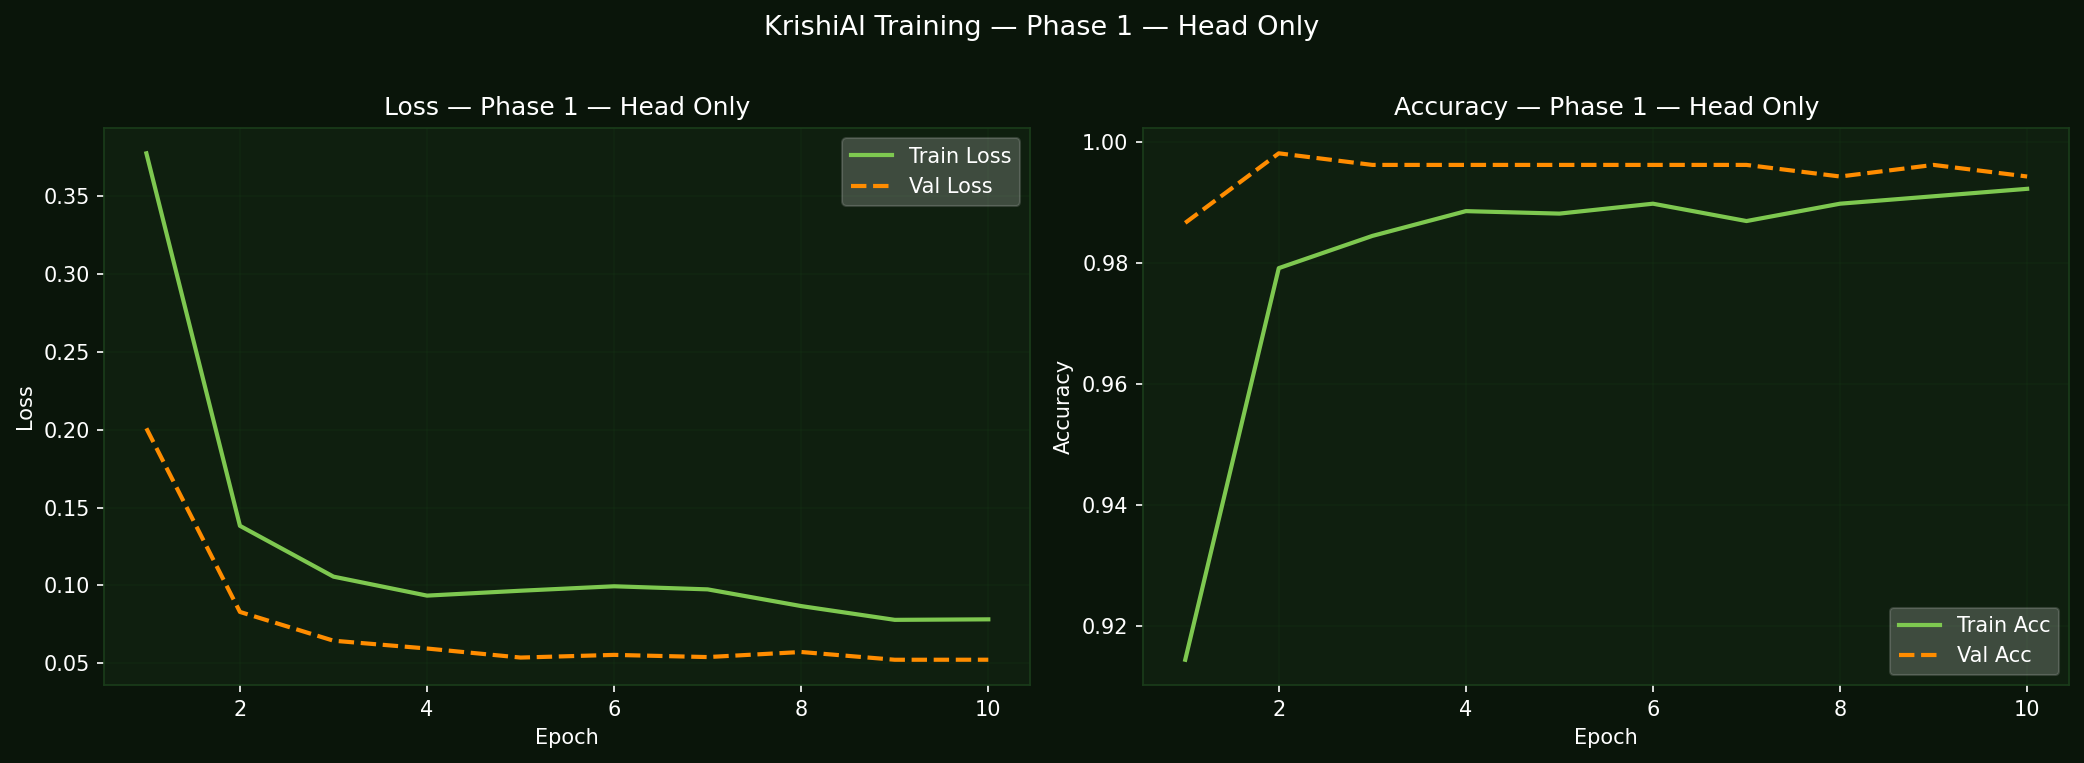

In [ ]:
from IPython.display import Image as IPyImage, display
p1_plot = os.path.join(PLOTS_DIR, "phase1_training_curves.png")
if os.path.exists(p1_plot):
    display(IPyImage(p1_plot))
else:
    print("Phase 1 was skipped or plot not generated yet.")


## ▶️ Phase 2 — Fine-Tune Top 30 Layers
> Automatically **resumes** from `best_phase2.keras` if it exists in Drive.

In [ ]:
# ── PHASE 2 — Fine-tune top 30 layers ───────────────────────────────────────
# Automatically skipped if Phase 2 is already fully done.

if TRAIN_STATE == "DONE":
    print("⏭️  Training already complete — skipping Phase 2.")
    hist2 = None

elif P2_EPOCHS_LEFT == 0:
    # Phase 2 fully done — just load the checkpoint
    print(f"⏭️  Phase 2 already finished ({p2_done} epochs). Loading checkpoint...")
    model = keras.models.load_model(CKPT_P2)
    ckpt_p2 = CKPT_P2
    hist2 = None
    print(f"   ✅ Loaded: {CKPT_P2}")

else:
    if p2_exists:
        # Resume Phase 2 from where it left off
        print(f"▶️  Resuming Phase 2 from checkpoint ({p2_done} epochs done, {P2_EPOCHS_LEFT} left)...")
        model = keras.models.load_model(CKPT_P2)
        ckpt_p2 = CKPT_P2
    else:
        # Phase 1 done, starting Phase 2 fresh
        print(f"▶️  Starting Phase 2 from Phase 1 checkpoint ({P2_EPOCHS_LEFT} epochs)...")
        model = keras.models.load_model(CKPT_P1)
        ckpt_p2 = CKPT_P2

        # Unfreeze top 30 layers
        base_layer = model.get_layer("efficientnetb0")
        base_layer.trainable = True
        for layer in base_layer.layers[:-30]:
            layer.trainable = False
        trainable_count = sum(1 for l in base_layer.layers if l.trainable)
        print(f"   Unfrozen layers: {trainable_count} / {len(base_layer.layers)}")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_FINETUNE),
        loss="categorical_crossentropy",
        metrics=["accuracy",
                 keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy"),
                 keras.metrics.AUC(name="auc", multi_label=False)]
    )

    callbacks_p2, _ = get_callbacks(phase=2)
    t2 = time.time()
    hist2 = model.fit(
        train_ds,
        epochs=P2_EPOCHS_LEFT,          # only run remaining epochs
        validation_data=val_ds,
        callbacks=callbacks_p2,
        class_weight=class_weights,
        verbose=1,
    )
    print(f"\n✅ Phase 2 done in {(time.time()-t2)/60:.1f} min")
    print(f"   Best val accuracy: {max(hist2.history['val_accuracy']):.4f}")
    plot_history(hist2, "Phase 2 — Fine-tuning", "phase2_training_curves.png")
    print(f"   Checkpoint saved to Drive: {CKPT_P2}")


⏭️  Training already complete — skipping Phase 2.


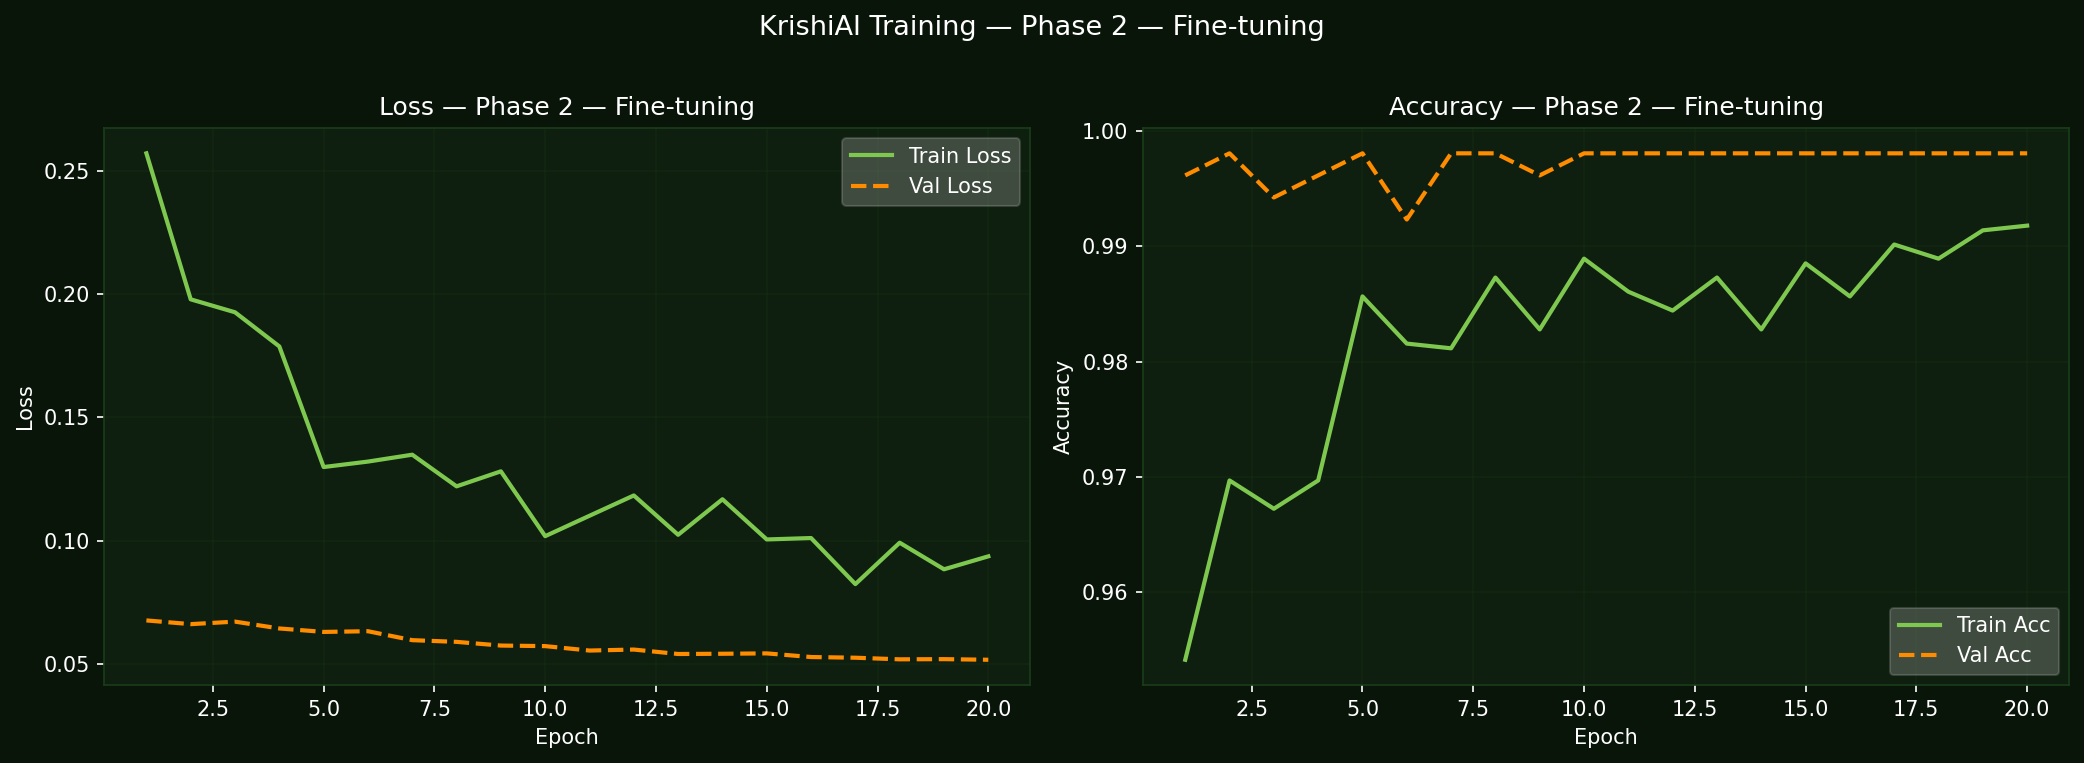

In [ ]:
from IPython.display import Image as IPyImage, display
p2_plot = os.path.join(PLOTS_DIR, "phase2_training_curves.png")
if os.path.exists(p2_plot):
    display(IPyImage(p2_plot))
else:
    print("Phase 2 was skipped or plot not generated yet.")


## 💾 Save Final Model + Merge History

In [ ]:
# ── SAVE FINAL MODEL + MERGE HISTORY ────────────────────────────────────────

if TRAIN_STATE == "DONE":
    print(f"✅ Final model already exists at: {FINAL}")
else:
    # Load best Phase 2 checkpoint as the final model
    final_model = keras.models.load_model(CKPT_P2)
    final_model.save(FINAL)
    print(f"✅ Final model saved → {FINAL}")
    print(f"   Size: {os.path.getsize(FINAL)/1e6:.1f} MB")

    print("\nValidation set evaluation:")
    val_results = final_model.evaluate(val_ds, verbose=1)
    for name, val in zip(final_model.metrics_names, val_results):
        print(f"  {name:<25} {val:.4f}")

# ── Merge new history with any previously saved history ──────────────────────
import json as _json

def _merge(old_list, new_hist, key):
    """Append new epoch values to existing history list."""
    existing = old_list.get(key, [])
    new_vals = new_hist.history.get(key, []) if new_hist else []
    return existing + new_vals

merged = {
    "phase1_accuracy":     _merge(SAVED_HISTORY, hist1, "accuracy"),
    "phase1_val_accuracy": _merge(SAVED_HISTORY, hist1, "val_accuracy"),
    "phase1_loss":         _merge(SAVED_HISTORY, hist1, "loss"),
    "phase1_val_loss":     _merge(SAVED_HISTORY, hist1, "val_loss"),
    "phase2_accuracy":     _merge(SAVED_HISTORY, hist2, "accuracy"),
    "phase2_val_accuracy": _merge(SAVED_HISTORY, hist2, "val_accuracy"),
    "phase2_loss":         _merge(SAVED_HISTORY, hist2, "loss"),
    "phase2_val_loss":     _merge(SAVED_HISTORY, hist2, "val_loss"),
}

with open(HIST_FILE, "w") as _f:
    _json.dump(merged, _f)

print(f"\n✅ Training history saved → {HIST_FILE}")
print(f"   Phase 1: {len(merged['phase1_accuracy'])} epochs recorded")
print(f"   Phase 2: {len(merged['phase2_accuracy'])} epochs recorded")
print()

# Final Drive summary
print("=" * 55)
print("GOOGLE DRIVE — SAVED FILES")
print("=" * 55)
for fname in ["best_phase1.keras", "best_phase2.keras", "krishiai_final.keras"]:
    p = os.path.join(MODELS_DIR, fname)
    if os.path.exists(p):
        print(f"  ✅ models/{fname}  ({os.path.getsize(p)/1e6:.1f} MB)")
    else:
        print(f"  ⬜ models/{fname}  — not yet saved")
print()
print("Next: open 04_step3_evaluate.ipynb")


✅ Final model already exists at: /content/drive/MyDrive/KrishiAI/models/krishiai_final.keras

✅ Training history saved → /content/drive/MyDrive/KrishiAI/logs/training_history.json
   Phase 1: 0 epochs recorded
   Phase 2: 0 epochs recorded

GOOGLE DRIVE — SAVED FILES
  ✅ models/best_phase1.keras  (21.1 MB)
  ✅ models/best_phase2.keras  (33.1 MB)
  ✅ models/krishiai_final.keras  (33.1 MB)

Next: open 04_step3_evaluate.ipynb
